In [ ]:
import pandas as pd
import pickle
import os
from glob import glob

ruta_pkl = "./"  
archivos = ['results0101.pkl','results0105.pkl','results0421.pkl','results0522.pkl']
lista_features = []
for archivo in archivos:
    try:
        with open(archivo, "rb") as f:
            contenido = pickle.load(f)
            features = list(contenido['features'].variable)
            lista_features=lista_features+features
    except Exception as e:
        print(f"[ERROR] Falló al procesar {archivo}: {e}")
lista_features=np.unique(lista_features)
df = pd.read_pickle("data_family.pkl")
exog = df['exog'].copy().ffill()[lista_features]
exog›

,Fiestas_patrias,IAC_Electricos_y_Hogar,IAC_Ferreteria_Minorista,Navidad,Norte_wspd,Pandemia,Primavera,Sur_prcp,bienes_durables,bienos_no_durables,cobre_fob,consumo_hogar_ipsfl,csi300_china,hierro_fob,imacec_no_minero,transferencias_corrientes_netas
dt,,,,,,,,,,,,,,,,
2017-01-01,0,92.681830,101.652937,0,11.943548,0,0.0,0.294565,2672.601837,12724.080283,2372.182886,28946.866181,3349.0,99.505775,92.663595,486.740283
2017-02-01,0,87.981846,93.188897,0,11.841071,0,0.0,1.791071,2627.571136,12538.999373,1985.691109,28589.568748,3430.2,68.453212,90.143487,495.920967
2017-03-01,0,103.651256,104.703678,0,11.411290,0,0.0,1.826613,2537.509735,12168.837554,2288.247627,27874.973884,3454.5,91.434381,102.285871,514.282333
2017-04-01,0,90.748686,90.067083,0,10.443333,0,0.0,2.828889,2482.269646,11917.152951,2220.521247,27484.550588,3477.2,74.299944,96.243721,517.580200
2017-05-01,0,103.005319,98.510308,0,10.938710,0,0.0,4.636828,2461.850870,11783.945565,2671.710871,27418.298860,3408.8,60.546277,97.280222,505.814567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,0,110.306372,103.103172,0,18.904839,0,0.0,4.932414,2655.357986,12979.360750,4367.766383,31876.078818,3333.2,127.793228,111.685315,467.520100
2024-09-01,1,102.448354,92.640846,0,15.501667,0,0.5,4.799000,2628.960437,12986.180026,4653.225437,31796.265131,3315.1,125.699035,106.938772,544.786100
2024-10-01,0,119.068710,113.922645,0,13.927419,0,1.0,1.150968,2628.960437,12986.180026,4681.660044,31796.265131,3934.8,87.044803,112.986265,544.786100


In [32]:
import pandas as pd
name='0522'
df_results = pd.read_pickle(f"results{name}.pkl")
best_models = (
    df_results['trials']
    .sort_values('mape_mean')
    .groupby('model', as_index=False)
    .first()
    .sort_values('mape_mean')
    .reset_index(drop=True)
)
best_models.to_csv("mejores_modelos_por_mape.csv", index=False)
best_models.sort_values('mape_mean')

,model,trial_number,params,mape_mean,mape_best
0,SARIMAX,43,"{'seasonal': True, 'm': 6, 'stepwise': False}",0.190793,0.156274
1,LSTM,48,"{'window_size': 16, 'units': 53, 'epochs': 36,...",0.193252,0.155362
2,GRU,36,"{'window_size': 18, 'units': 75, 'epochs': 81,...",0.193840,0.131399
3,HW,12,"{'trend': None, 'seasonal': 'mul', 'seasonal_p...",0.204742,0.131754
4,Prophet,36,"{'growth': 'linear', 'seasonality_prior_scale'...",0.235321,0.172854
5,Silverkite,43,"{'growth': 'sqrt', 'fit_algorithm': 'linear', ...",0.263267,0.125697
6,Transformer,37,"{'window_size': 8, 'head_size': 47, 'num_heads...",0.267465,0.132307
7,RegresionTree,43,"{'max_depth': 20, 'min_samples_split': 6, 'min...",0.401291,0.256590
8,RandomForest,42,"{'n_estimators': 74, 'max_depth': 21, 'min_sam...",0.415508,0.355207
9,MLP,19,"{'hidden_layer_sizes': (64, 32), 'max_iter': 600}",0.461272,0.426273


In [33]:
df_results['features'][df_results['features']['correlación']>0.4]

,variable,lag,correlación
0,Primavera,2,0.810100
3,Fiestas_patrias,3,0.624057
6,IAC_Electricos_y_Hogar,0,0.595863
7,Sur_prcp,4,0.513265
12,bienos_no_durables,0,0.431839
13,Norte_wspd,1,0.427677
16,cobre_fob,1,0.408613


In [34]:
from aux import *
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error
from models import *
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

df = pd.read_pickle("data_family.pkl")
exog = df['exog'].copy().ffill()
sales_by_family = df['sales_by_family']
familias = pd.read_csv("familias.csv")
data_by_family = {
    fam: format_as_year_month(sales_by_family[sales_by_family['family'] == fam].copy())
    for fam in sales_by_family['family'].unique()
}
for fam in data_by_family:
    data_by_family[fam], _ = limpiar_outliers_x_agrupacion(data_by_family[fam], 'family', 'sale_amount_MM')
target_col = 'sale_amount_MM'
ignore_col = [] 
negatives_reg_col = [] 
df_results = pd.read_pickle(f"results{name}.pkl")
best_models = (
    df_results['trials']
    .sort_values('mape_mean')
    .groupby('model', as_index=False)
    .first()
    .sort_values('mape_mean')
    .reset_index(drop=True)
)
best_models.to_csv("mejores_modelos_por_mape.csv", index=False)
models_results = df_results['trials'].reset_index(drop=True)
models_results = models_results.loc[models_results.groupby('model')['mape_mean'].idxmin()]
funcs = dict(zip(['HW','SARIMAX','Silverkite','LSTM','GRU','Transformer','ElasticNet','Prophet','MLP','RegresionTree','RandomForest'],
            [fit_predict_eval_hw,fit_predict_eval_autoarima,fit_predict_eval_silverkite,fit_predict_eval_lstm,
fit_predict_eval_gru,fit_predict_eval_transformer,fit_predict_eval_elastic_net,
fit_predict_eval_prophet, fit_predict_eval_mlp,fit_predict_eval_tree,fit_predict_eval_rf]))

MODELO='RandomForest'
mape_list = []
model_params=models_results.query(f"model == '{MODELO}'")['params'].iloc[0]
features=df_results['features']

if MODELO in ['LSTM','GRU','Transformer','ElasticNet','Prophet','MLP','RegresionTree','RandomForest']:
    df_final=exog[features.variable.to_list()].join(data_by_family[name]['sale_amount_MM']).assign(ds=exog.index)
else:
    df_final=exog[features.variable.to_list()].join(data_by_family[name]['sale_amount_MM'])
df_final['y'] = df_final[target_col]

In [35]:
start_test_date = pd.to_datetime('2023-12-01')
fechas = pd.date_range(start=start_test_date, end=max(df_final.index), freq='MS')
results = pd.DataFrame(index=fechas)
results.index.name = 'ds'
for idx, var in enumerate(funcs):
    MODELO=var
    mape_list = []
    model_params=models_results.query(f"model == '{MODELO}'")['params'].iloc[0]
    features=df_results['features']
    if MODELO in ['LSTM','GRU','Transformer','ElasticNet','Prophet','MLP','RegresionTree','RandomForest']:
        df_final=exog[features.variable.to_list()].join(data_by_family[name]['sale_amount_MM']).assign(ds=exog.index)
    else:
        df_final=exog[features.variable.to_list()].join(data_by_family[name]['sale_amount_MM'])
    df_final['y'] = df_final[target_col]
    training_set=df_final.copy().loc['2017-05-01':str(start_test_date)]
    test_set=df_final.copy().loc[str(start_test_date)::]
    model, y_pred,scaler = funcs[MODELO](training_set, test_set, model_params)
    y_pred.index=fechas[-len(y_pred)::]
    results=results.join(pd.DataFrame(y_pred).drop('ds', errors='ignore',axis=1).rename(columns={'pred_test':MODELO}),how='left')
results=results.dropna()

Fitting 3 folds for each of 1 candidates, totalling 3 fits


/Users/sebastianulloa/.virtualenvs/py310/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/sebastianulloa/.virtualenvs/py310/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2025-05-11 17:51:38 cmdstanpy [DEBUG]: input tempfile: /var/folders/_2/b07hnlxx27j566j7xpz5w05m0000gn/T/tmpejpkogm0/fh56pqfu.json
2025-05-11 17:51:38 cmdstanpy [DEBUG]: input tempfile: /var/folders/_2/b07hnlxx27j566j7xpz5w05m0000gn/T/tmpejpkogm0/2w3cpz3m.json
2025-05-11 17:51:38 cmdstanpy [DEBUG]: idx 0
2025-05-11 17:51:38 cmdstanpy [DEBUG]: running CmdStan, num_threads: None
2025-05-11 17:51:38 cmdstanpy [DEBUG]: CmdStan args: ['/Users/sebastianulloa/.virtualenvs/py310/lib/python3.10/site-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=79924', 'data', 'file=/var/folders/_2/b07hnlxx27j566j7xpz5w05m0000gn/T/tmpejpkogm0/fh56pqfu.json', 'init=/var/folders/_2/b07hnlxx27j566j7xpz5w05m0000gn/T/tmpejpkogm0/2w3cpz3m.json', 'output', 'file=/var/folders/_2/b07hnlxx27j566j7xpz5w05m0000gn/T/tmpejpkogm0/prophet_modelqfkblh10/prophet_model-20250511175138.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']


17:51:38 - cmdstanpy - INFO - Chain [1] start processing


2025-05-11 17:51:38 cmdstanpy [INFO]: Chain [1] start processing


17:51:42 - cmdstanpy - INFO - Chain [1] done processing


2025-05-11 17:51:42 cmdstanpy [INFO]: Chain [1] done processing


/Users/sebastianulloa/.virtualenvs/py310/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(


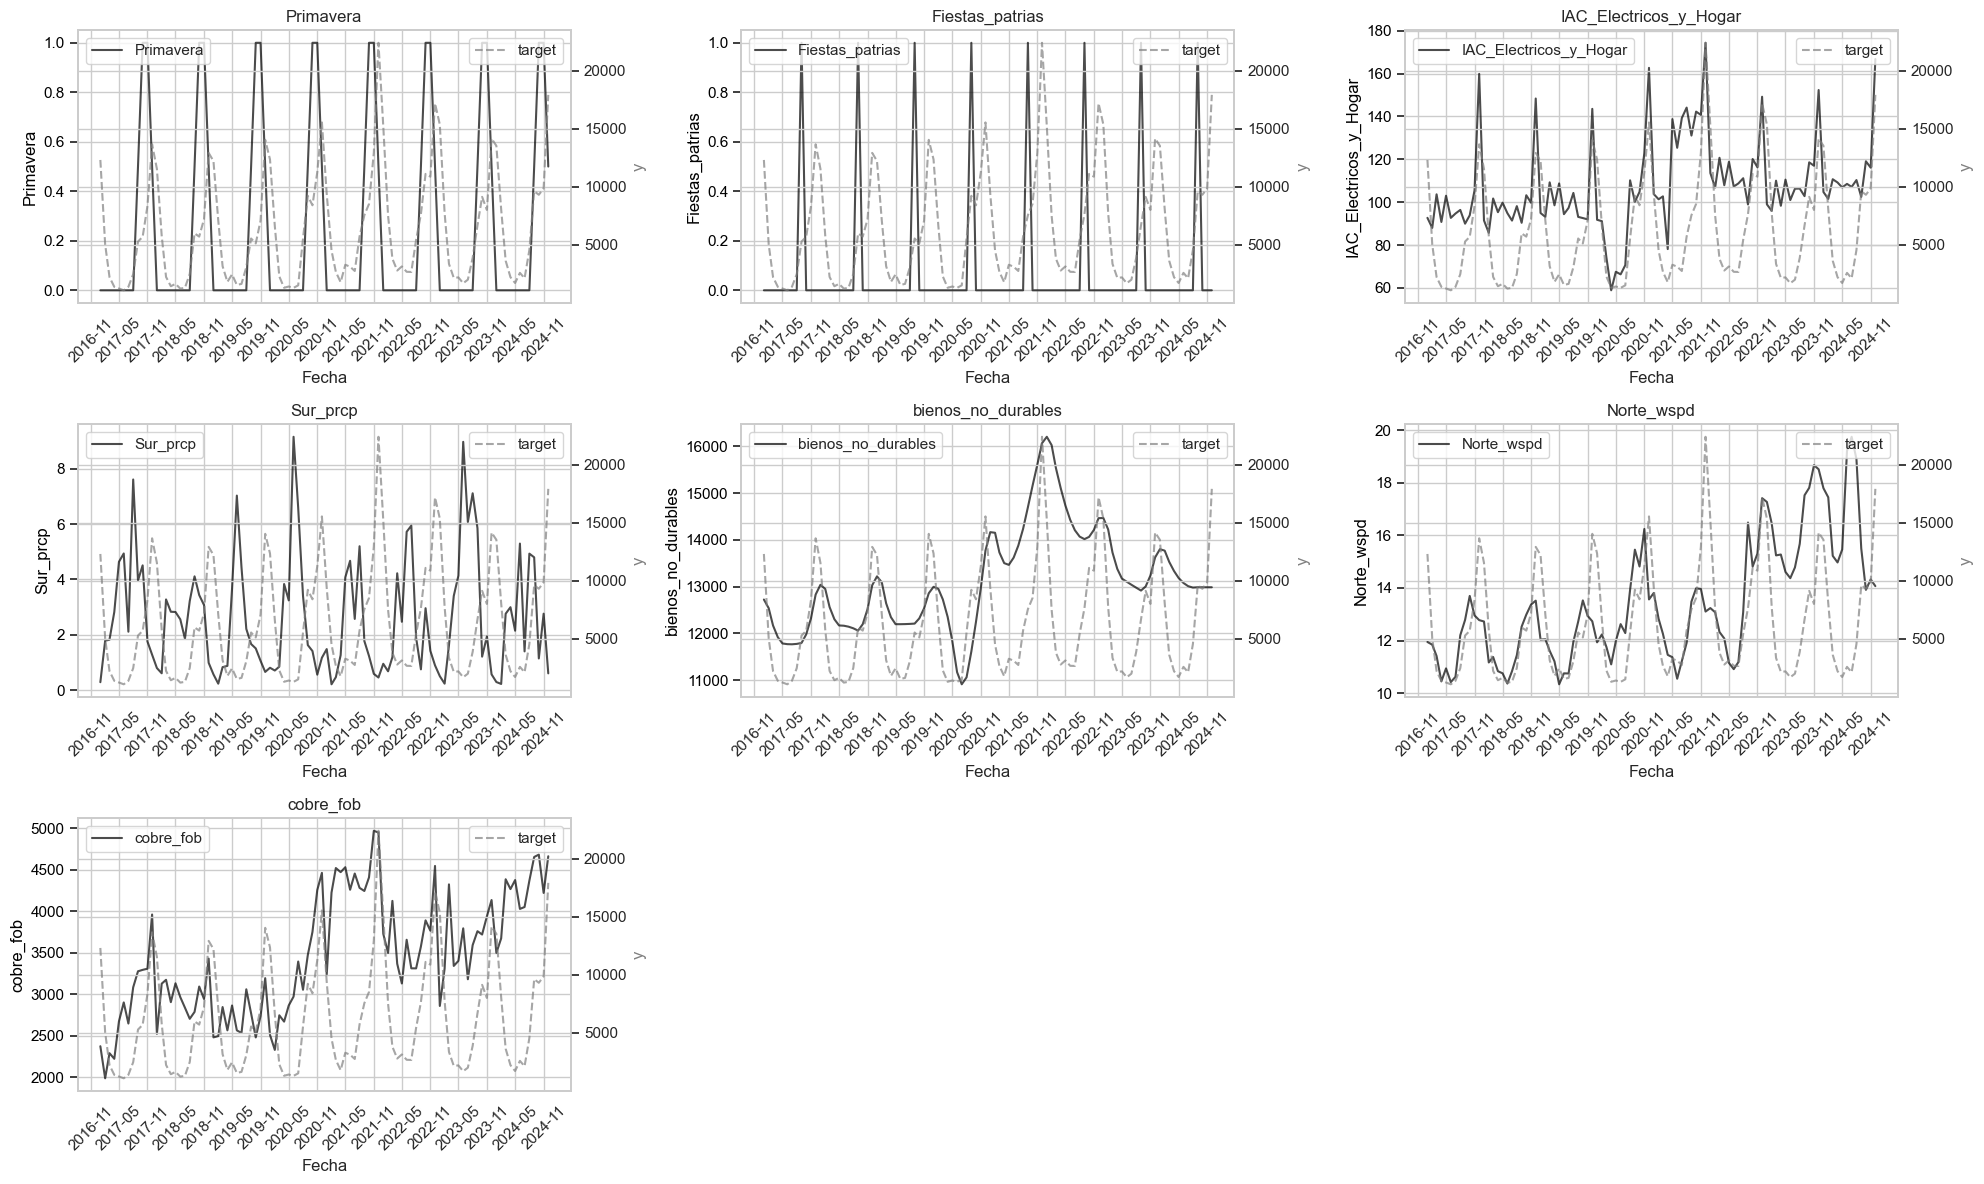

In [36]:
%matplotlib inline
plt.close('all') 
sns.set(style="whitegrid")
variables = features.variable.to_list()
cols = 3
rows = (len(variables) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4), squeeze=False)
axes = axes.flatten()
for idx, var in enumerate(variables):
    ax1 = axes[idx]
    sns.lineplot(x=df_final.index, y=df_final[var], ax=ax1,
                 label=var, color='black', alpha=0.7)
    ax1.set_xlabel('Fecha')
    ax1.set_ylabel(var, color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.legend(loc='upper left')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax1.tick_params(axis='x', rotation=45)
    ax2 = ax1.twinx()
    sns.lineplot(x=df_final.index, y=df_final['y'], ax=ax2,
                 label='target', linestyle='--', color='gray', alpha=0.7)
    ax2.set_ylabel('y', color='gray')
    ax2.legend(loc='upper right')
    ax1.set_title(f'{var}')
for idx in range(len(variables), len(axes)):
    fig.delaxes(axes[idx])
fig.tight_layout()
plt.show()

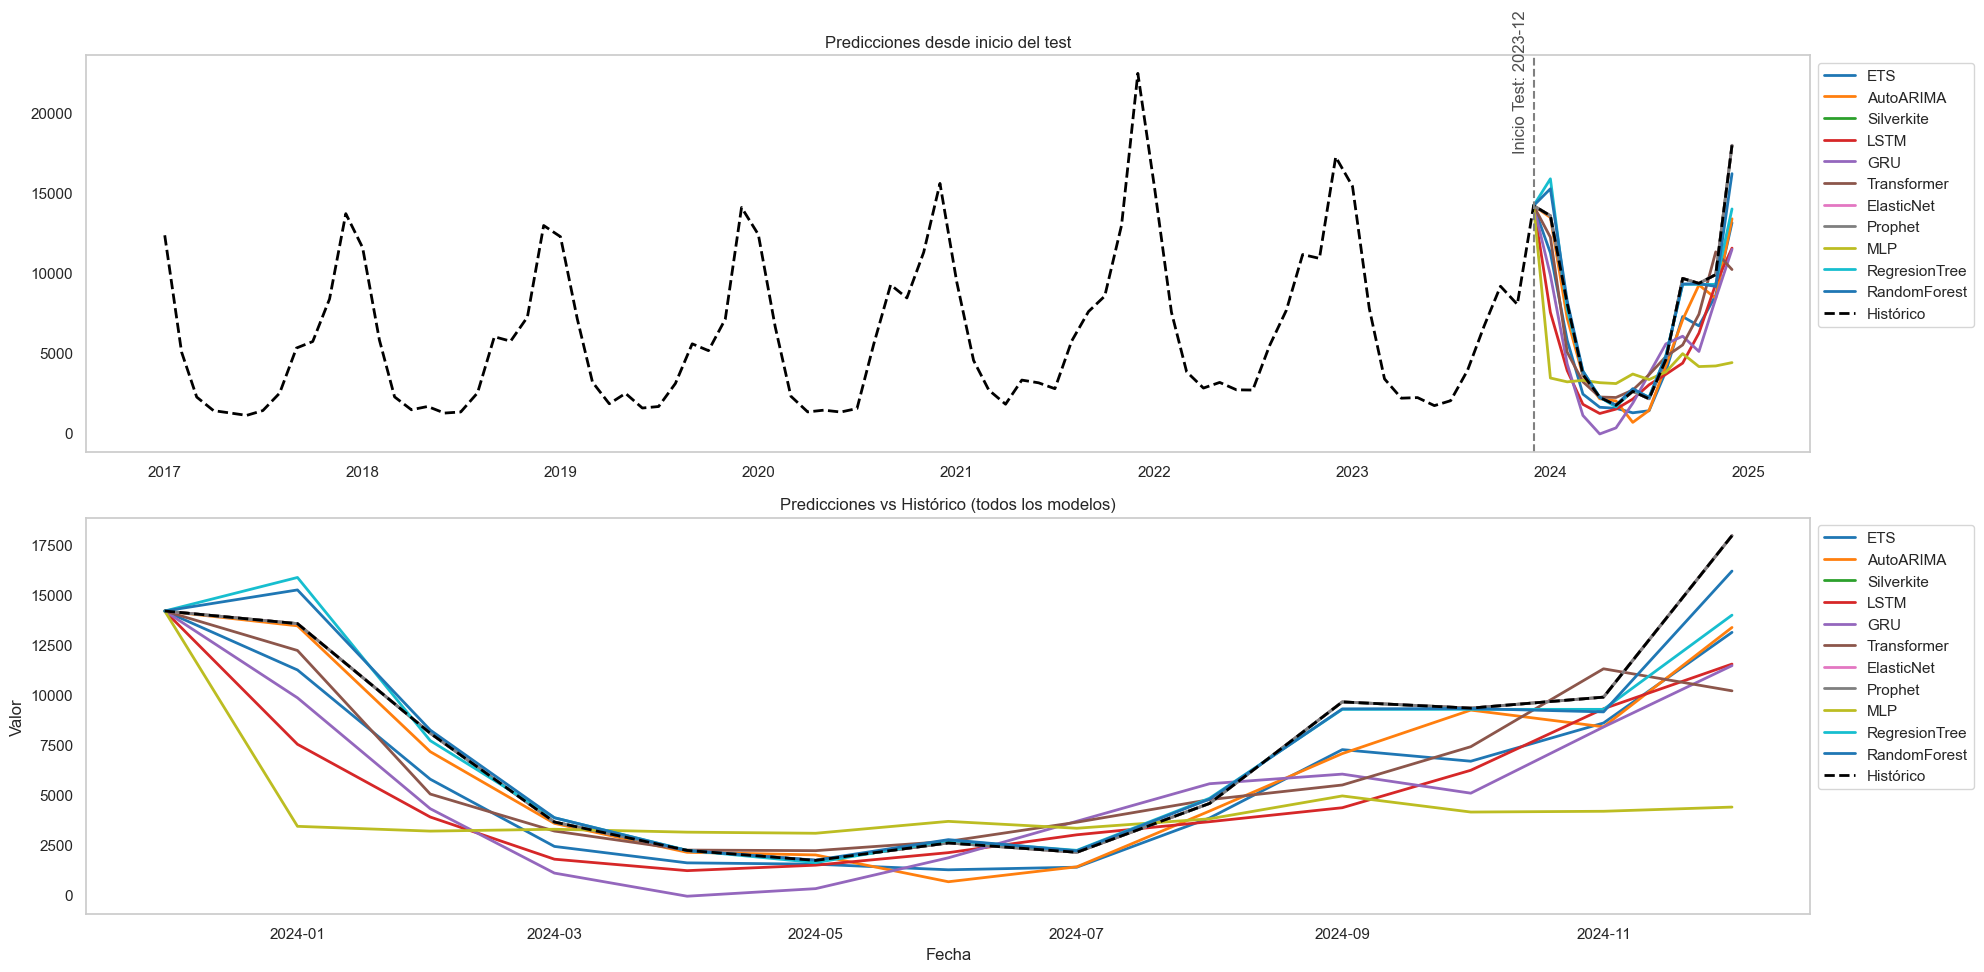

In [37]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
time_series = pd.DataFrame(df_final.copy()['y']).join(results.copy())
for i in results.columns:
    time_series[i] = time_series[i].fillna(time_series['y'])
modelos = [col for col in time_series.columns if col != 'y']
colores = sns.color_palette("tab10", n_colors=len(modelos))
fig, axes = plt.subplots(2, 1, figsize=(20, 10))
for modelo, color in zip(modelos, colores):
    pred = time_series[time_series.index >= start_test_date][modelo]
    axes[0].plot(pred.index, pred, label=modelo, color=color, linewidth=2)
axes[0].plot(
    time_series.index,
    time_series['y'],
    label="Histórico",
    color='black',
    linestyle='--',
    linewidth=2
)
axes[0].axvline(x=start_test_date, color='gray', linestyle='--')
axes[0].text(start_test_date - pd.Timedelta(days=25),
             axes[0].get_ylim()[1] * 0.75,
             start_test_date.strftime('Inicio Test: %Y-%m'),
             horizontalalignment='center', color='#505050', rotation=90)
axes[0].set_title("Predicciones desde inicio del test")
axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1))
axes[0].grid()
for color, model in zip(colores, results.columns):
    axes[1].plot(
        time_series.loc[str(start_test_date)::].index,
        time_series[model].loc[str(start_test_date)::],
        label=model,
        color=color,
        linestyle='-',
        linewidth=2
    )
axes[1].plot(
    time_series.loc[str(start_test_date)::].index,
    time_series['y'].loc[str(start_test_date)::],
    label="Histórico",
    color='black',
    linestyle='--',
    linewidth=2
)
axes[1].set_title("Predicciones vs Histórico (todos los modelos)")
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Valor')
axes[1].legend(loc='upper left', bbox_to_anchor=(1, 1))
axes[1].grid()
plt.tight_layout()
plt.show()